<a href="https://colab.research.google.com/github/YingKi-UPHPI/MLimage/blob/main/YK_assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basics of Image Processing

Welcome to the first coding assignment for *Machine Learning for Image Analysis*. This notebook helps you get comfortable with Jupyter, Python, and simple coding tasks used in image‑based ML.

You will complete **four short, independent tasks**. Each task is implemented as a Python function with an empty body; your job is to fill in the body exactly as described. The notebook includes small self‑test cells you can run locally to check your work before submitting.

**Rules:**

- Keep the function names and signatures **exactly** as given; the autograder relies on them.  
- Do **not** add or remove arguments, and do **not** create helper functions outside the task bodies.
- You may add extra cells for your own experiments, but they must **not** change the required task functions.  
- You may import other libraries than `matplotlib`, `numpy`, and `opencv-python` for your own experiments. But do **not** use these libraries within the task functions, otherwise the autograder will not be able to run your code.

**Submission:**
Upload the finished notebook to the corresponding assignment on Moodle once all self‑tests pass.


## Grading

The table below lists each task and the name of the function you must submit.  
You will earn the listed number of points if your implementation passes the corresponding tests.

| Task | Submitted function | Points |
|:-----|:-------------------|:------:|
| [Task 1](#task-image-loading) | `load_rgb_image` | 10 |
| [Task 2](#task-image-resizing) | `resize_image` | 10 |
| [Task 3](#task-rgb-to-grayscale) | `rgb_to_average_grayscale` | 10 |
| [Task 4](#task-segmentation-by-thresholding) | `segment_by_threshold` | 10 |
|  | **Total** | **40** |


## Google Colab

Google Colab allows you to write and execute Python notebooks in your browser, with
- close to zero configuration required
- free but limited access to GPUs (Nvidia Tesla K80)
- easy sharing and collaborative work on a single file.

Just like local python notebooks, this file consists of (markdown) text cells and python code cells. You can add and delete cells and move them around in this document. You can change the runtime type from CPU to GPU (`Runtime-> Change runtime type -> Hardware Accelerator -> GPU`) to speed up your computations when using a GPU-capable machine learning library. You can import your python libraries, load data from the web and even install new libraries on the virtual machine by typing `!pip install <libraryname>` , the exclamation mark lets you escape the python environment and type on the commandline.

**Requirements** To use Colab, you must have a Google account with an associated Google Drive.

**Workflow** For the assignments, you can keep on working locally with the python notebooks that we provide for the practical. But we recommend to use colab, because it offers a nice way of working together as a group on the practical assignments. Furthermore the free GPU will be useful for future assignments that require more computational ressources.

**Limitations** Ressources on colab are not guaranteed and therefore there might be times where some ressources cannot get allocated. If you're idle for 90 minutes or your connection time exceeds the maximum of 12 hours, the colab virtual machine will disconnect. This means that unsaved progress such as model parameters are lost.

**Assignment submission** Just download the notebook at `File->Download .ipynb` and hand it in by uploadiing it to the Moodle assignment.

In [1]:
# NOTE: Execute the cell below before running any other code.

# Install libraries in Colab
!pip install -q matplotlib numpy opencv-python

In [2]:
# Download additonal utility files and data (run once in Colab)
import os

if not os.path.exists("data"):
    !git clone https://github.com/hpi-mlia-2026/coding_assignments.git
    %cd coding_assignments/assignment_01

Cloning into 'coding_assignments'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 50 (delta 9), reused 49 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 8.80 MiB | 24.97 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/coding_assignments/assignment_01


## Image processing

This notebook covers basic image operations you will reuse throughout the course.  
You will read an image, resize it, convert to grayscale, and finally apply a simple threshold‑based segmentation.


In [3]:
# Import libraries
import numpy as np
import cv2

%matplotlib inline
from matplotlib import pyplot as plt

### Task: Image loading

Implement a function named `load_rgb_image(path)` that reads an image file and returns a NumPy array with

- shape `(H, W, 3)` where `H` and `W` are the image height and width,
- data type `float32`,
- pixel values normalized to the range `[0, 1]`,
- and color channels in **RGB** order.

You may use **matplotlib** or **opencv (cv2)** to perform the loading; no other libraries are allowed.

Note 1: By default, cv2 uses **BGR** order for color channels, while matplotlib uses **RGB**. You may need to swap the channels before returning the array.

Note 2: Usually, JPEG images are stored as integeres in the range `[0, 255]`, while PNG images are stored as floats in the range `[0, 1]`. You may need to convert the data type of the loaded image to `float32` and normalize the pixel values to `[0, 1]` before returning it.


In [4]:
def load_rgb_image(path):
    """
    Load an image from the given path and return it
    as numpy array with pixel values normalized to [0, 1]
    and data type float32. The channels should be in RGB order.
    """
    ###########################################################################
    #                         START OF YOUR CODE                              #
    ###########################################################################
    img_bgr = cv2.imread(path)

    if img_bgr is None:
        raise ValueError(f"Could not load image from path: {path}")

    # Swap channels from BGR (OpenCV default) to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Convert data type to float32 and normalize to [0, 1]
    # Since OpenCV loads standard JPEGs/PNGs as uint8 in the [0, 255] range,
    # we can safely divide by 255.0.
    array = img_rgb.astype(np.float32) / 255.0

    ###########################################################################
    #                         END OF YOUR CODE                                #
    ###########################################################################

    return array

Array shape: (H, W, C) = (205, 246, 3)
Correct shape: (H, W, C) = (205, 246, 3)

Maximum value: 1.0
Correct maximum value: 1.0

Data type: float32
Correct data type: float32


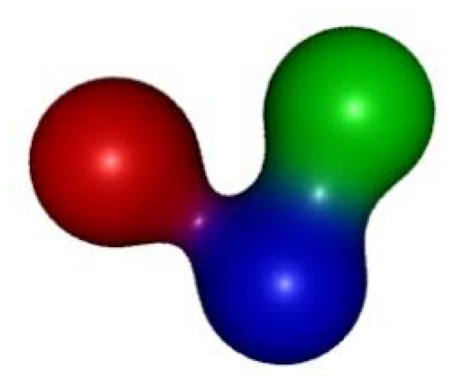

In [5]:
# Self-test

img_path = "rgb_blobs.jpg"
img_array = load_rgb_image(img_path)

print(f"Array shape: (H, W, C) = {img_array.shape}")
print(f"Correct shape: (H, W, C) = (205, 246, 3)\n")

print(f"Maximum value: {img_array.max()}")
print(f"Correct maximum value: 1.0\n")

print(f"Data type: {img_array.dtype}")
print(f"Correct data type: float32")

# Plot the image
plt.imshow(img_array)
plt.axis('off')
plt.show()

Before moving on, check that your image array uses RGB ordering.  
Run the following cell to extract the first channel and display it.  
The result should look like the red‑channel example shown below:

![red channel example](https://github.com/hpi-mlia-2026/coding_assignments/blob/main/assignment_01/rgb_blobs_red_channel.png?raw=1)


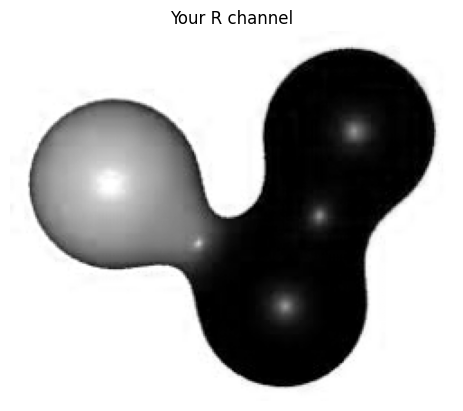

In [6]:
# Self-test: Order of RGB channels

r_channel = img_array[:, :, 0]
plt.imshow(r_channel)
plt.set_cmap('grey')
plt.axis('off')
plt.title('Your R channel')
plt.show()

### Task: Image resizing

Write `resize_image(img_array, size)` which takes an image array (shape `(H,W,3)`) and a target `size` tuple `(new_h, new_w)`.
Return a new NumPy array containing the image resized to that height and width.  
You may use `cv2.resize` with **bilinear interpolation** – you do **not** need to implement the interpolation yourself.


In [7]:
def resize_image(img_array, size):
    """
    img_array: numpy array of the image
    size: tuple (new_h, new_w)
    returns: numpy array of the image resized to the given size using bilinear interpolation
    """
    ###########################################################################
    #                         START OF YOUR CODE                              #
    ###########################################################################

    resized = None

    ###########################################################################
    #                         END OF YOUR CODE                                #
    ###########################################################################
    return resized


In [8]:
# Self-test

size = (100, 100)
resized = resize_image(img_array, size)

print(f"Resized shape: (H, W, C) = {resized.shape}")
print(f"Correct resized shape: (H, W, C) = (100, 100, 3)\n")

# Plot the image
plt.imshow(resized)
plt.axis('off')
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

### Task: RGB to grayscale

Convert a color image to grayscale by averaging its three channels.  
Implement `rgb_to_average_grayscale(img_array)` which takes an RGB array of shape `(H,W,3)` and returns a 2‑D array `(H,W)` of floats in `[0,1]` equal to the average of the red, green and blue values at each pixel.  
(This is **not** the same as the luminance conversion used by `cv2.cvtColor`; the goal here is to practice array operations.)


In [ ]:
def rgb_to_average_grayscale(img_array):
    """
    img_array: numpy array of shape (H, W, 3) in RGB format
    returns: numpy array of shape (H, W) which is the average of all three color channels, dtype float32, values in [0,1]
    """
    ###########################################################################
    #                         START OF YOUR CODE                              #
    ###########################################################################

    grayscale_array = None

    ###########################################################################
    #                         END OF YOUR CODE                                #
    ###########################################################################
    return grayscale_array

In [ ]:
# Self-test

average_grayscale = rgb_to_average_grayscale(resized)

print(f"Greyscale shape: (H, W) = {average_grayscale.shape}")
print(f"Correct grayscale shape: (H, W) = (100, 100)\n")

print(f"Grayscale value of example pixel: {average_grayscale[50, 50]}")
print(f"Correct grayscale value of example pixel: {0.2502290904521942}\n")

plt.imshow(average_grayscale)
plt.axis("off")
plt.show()


### Task: Segmentation by thresholding

Implement `segment_by_threshold(grayscale_img, threshold)` where

- `grayscale_img` is a 2‑D NumPy array of floats in `[0,1]` (output of the previous task),
- `threshold` is a float in `[0,1]`.

The function should return a binary mask of the same shape where pixels above the threshold are set to `1` and others to `0`.  
Return type may be boolean or `uint8`; the self‑test casts to `uint8` for display.


In [ ]:
def segment_by_threshold(grayscale_img, threshold):
    """
    grayscale_img: input image as normalized numpy array, shape (H, W)
    threshold: float in [0, 1]
    returns: binary mask as numpy array shape (H, W), dtype: uint8
    """
    ###########################################################################
    #                         START OF YOUR CODE                              #
    ###########################################################################

    binary_mask = None

    ###########################################################################
    #                         END OF YOUR CODE                                #
    ###########################################################################
    return binary_mask

Now let's try the thresholding method on a real image.  
The file `loeffelhund.png` shows a very fine Löffelhund (bat‑eared fox).
Take a few moments to appreciate the undeniable charm and elegance of this exquisite animal.

After converting the image to grayscale and applying a threshold of `0.6`, you should obtain a mask resembling the example below.

Original image:

![Original image](https://github.com/hpi-mlia-2026/coding_assignments/blob/main/assignment_01/loeffelhund.png?raw=1)

Thresholded result (threshold=0.6):

![Thresholded image](https://github.com/hpi-mlia-2026/coding_assignments/blob/main/assignment_01/loeffelhund_threshold.png?raw=1)


In [ ]:
# Self-test

new_image = plt.imread('loeffelhund.png')
new_grayscale = rgb_to_average_grayscale(new_image)
mask = segment_by_threshold(new_grayscale, 0.6)

plt.imshow(mask)
plt.axis('off')
plt.show()

## Submission

When all self‑test cells run without errors, save this notebook and upload it to Moodle.  
Before submitting, make sure:

- You have **not** changed the names or signatures of the required functions.  
- You are **not** using additional libraries than `numpy`, `matplotlib`, and `opencv-python` in the task functions.
- You are **not** using any helper functions defined outside of the task functions.

Good luck!
